In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Titanic dataset directly from URL
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("=" * 40)
print("DATASET INFORMATION")
print("=" * 40)
print("\n📌 Shape:", df.shape)
print("\n📌 Columns:", df.columns.tolist())
print("\n📌 Data Types:\n", df.dtypes)
print("\n📌 Missing Values:\n", df.isnull().sum())
print("\n📌 Duplicate Rows:", df.duplicated().sum())

DATASET INFORMATION

📌 Shape: (891, 12)

📌 Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

📌 Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

📌 Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

📌 Duplicate Rows: 0


In [4]:
print("📊 Statistical Summary:")
df.describe()

📊 Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Before cleaning
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())

# Fix missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

# After cleaning
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())
print("\n✅ Data cleaning complete!")

Missing values BEFORE cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values AFTER cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

✅ Data cleaning complete!


📊 Survival Rate:
Did Not Survive: 61.6%
Survived: 38.4%


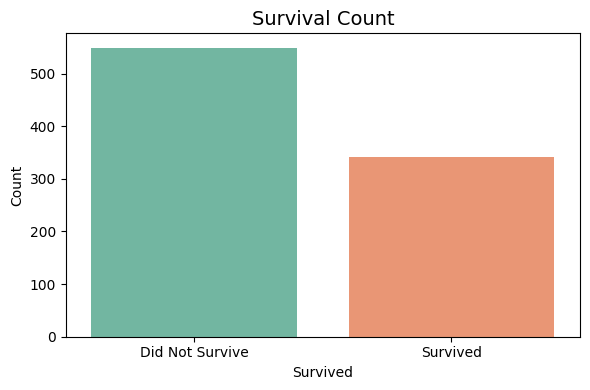

📌 Insight: Only 38.4% of passengers survived


In [6]:
survival_rate = df['Survived'].value_counts(normalize=True) * 100

print("📊 Survival Rate:")
print(f"Did Not Survive: {survival_rate[0]:.1f}%")
print(f"Survived: {survival_rate[1]:.1f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count', fontsize=14)
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda1_survival_count.png')
plt.show()

print("📌 Insight: Only 38.4% of passengers survived")

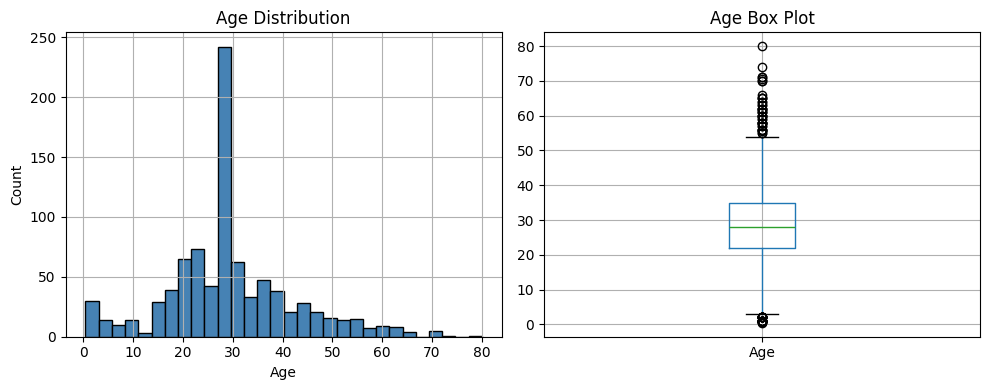

📌 Insight: Average age = 29.4 years
📌 Insight: Age range = 0 to 80 years


In [7]:
plt.figure(figsize=(10,4))

# Histogram
plt.subplot(1,2,1)
df['Age'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Box Plot
plt.subplot(1,2,2)
df.boxplot(column='Age')
plt.title('Age Box Plot')

plt.tight_layout()
plt.savefig('eda2_age_analysis.png')
plt.show()

print(f"📌 Insight: Average age = {df['Age'].mean():.1f} years")
print(f"📌 Insight: Age range = {df['Age'].min():.0f} to {df['Age'].max():.0f} years")

📊 Gender Distribution:
Sex
male      577
female    314
Name: count, dtype: int64

📊 Survival by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


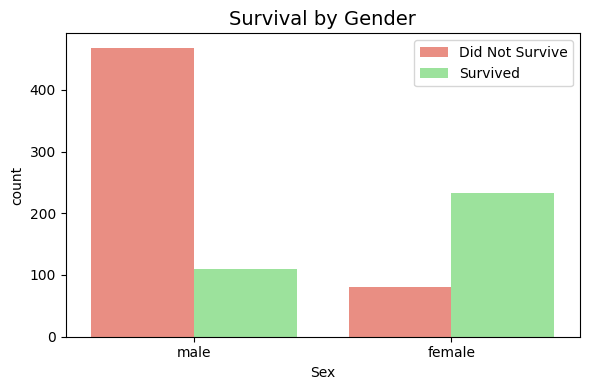

📌 Insight: 74% of females survived vs only 19% of males


In [8]:
print("📊 Gender Distribution:")
print(df['Sex'].value_counts())
print("\n📊 Survival by Gender:")
print(df.groupby('Sex')['Survived'].mean() * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df,
              palette={0:'salmon', 1:'lightgreen'})
plt.title('Survival by Gender', fontsize=14)
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.savefig('eda3_gender_survival.png')
plt.show()

print("📌 Insight: 74% of females survived vs only 19% of males")

📊 Survival Rate by Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


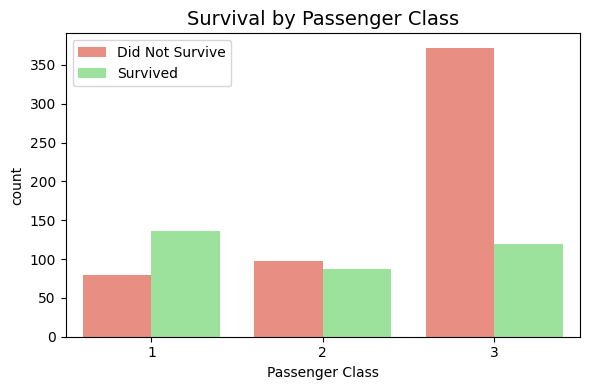

📌 Insight: 1st class had 63% survival vs 24% in 3rd class


In [9]:
print("📊 Survival Rate by Class:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df,
              palette={0:'salmon', 1:'lightgreen'})
plt.title('Survival by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.savefig('eda4_class_survival.png')
plt.show()

print("📌 Insight: 1st class had 63% survival vs 24% in 3rd class")

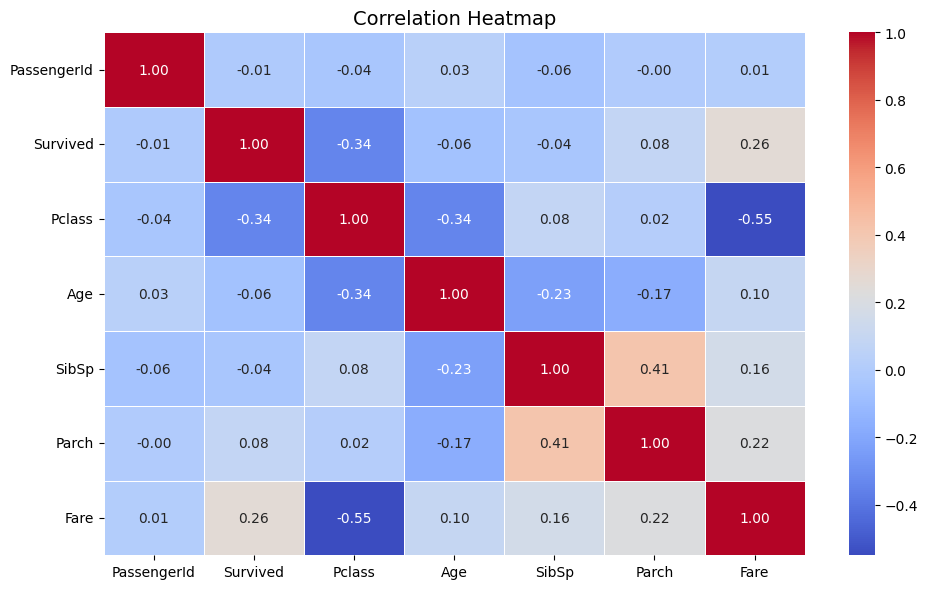

📌 Insight: Fare and Pclass are negatively correlated
📌 Insight: Pclass and Survived show negative correlation


In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('eda6_correlation.png')
plt.show()

print("📌 Insight: Fare and Pclass are negatively correlated")
print("📌 Insight: Pclass and Survived show negative correlation")

In [11]:
print("=" * 50)
print("📋 EDA SUMMARY — KEY FINDINGS")
print("=" * 50)
print(f"✅ Total Passengers : {len(df)}")
print(f"✅ Survival Rate    : {df['Survived'].mean()*100:.1f}%")
print(f"✅ Average Age      : {df['Age'].mean():.1f} years")
print(f"✅ Female Survival  : {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"✅ Male Survival    : {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"✅ 1st Class Surv.  : {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"✅ 3rd Class Surv.  : {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print("=" * 50)

📋 EDA SUMMARY — KEY FINDINGS
✅ Total Passengers : 891
✅ Survival Rate    : 38.4%
✅ Average Age      : 29.4 years
✅ Female Survival  : 74.2%
✅ Male Survival    : 18.9%
✅ 1st Class Surv.  : 63.0%
✅ 3rd Class Surv.  : 24.2%


In [12]:
from google.colab import files

charts = ['eda1_survival_count.png',
          'eda2_age_analysis.png',
          'eda3_gender_survival.png',
          'eda4_class_survival.png',
          'eda5_fare_analysis.png',
          'eda6_correlation.png']

for chart in charts:
    files.download(chart)

print("✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: eda5_fare_analysis.png